# Cell 1 — Singapore HDB House Price Monotonicity Lab

This notebook builds a small ReLU house-price model on a Singapore housing dataset and prepares a monotonicity property for the formal-verification lab.

Verification target: when floor area increases and other features stay fixed, the predicted price should not decrease.

In [2]:
# Cell 2 — Imports and reproducibility
import json
import math
import re
from pathlib import Path
from urllib.request import urlopen

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

import torch
from torch import nn
from torch.utils.data import DataLoader, TensorDataset

plt.style.use('seaborn-v0_8-whitegrid')
SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    device = torch.device('cuda')
elif torch.backends.mps.is_available():
    device = torch.device('mps')
else:
    device = torch.device('cpu')
print('device =', device)

device = mps


# Cell 3 — Data source

We use the Singapore HDB resale flats dataset from data.gov.sg. It is a real Singapore housing dataset with numeric and categorical fields.

Dataset id: `d_8b84c4ee58e3cfc0ece0d773c8ca6abc`

In [4]:
# Cell 4 — Download once, persist locally, and reload on reruns
from pathlib import Path

RESOURCE_ID = 'd_8b84c4ee58e3cfc0ece0d773c8ca6abc'
API = 'https://data.gov.sg/api/action/datastore_search'
DATA_DIR = Path('formal-verification/data')
DATA_DIR.mkdir(parents=True, exist_ok=True)
CACHE_PATH = DATA_DIR / 'hdb_resale_flat_prices_jan2017_onwards.csv'

def fetch_hdb_rows(limit=5000, max_rows=30000):
    rows = []
    offset = 0
    while len(rows) < max_rows:
        url = f'{API}?resource_id={RESOURCE_ID}&limit={limit}&offset={offset}'
        with urlopen(url) as resp:
            payload = json.load(resp)
        chunk = payload['result']['records']
        if not chunk:
            break
        rows.extend(chunk)
        offset += limit
        if len(chunk) < limit:
            break
    return pd.DataFrame(rows)

if CACHE_PATH.exists():
    raw = pd.read_csv(CACHE_PATH)
    print(f'loaded cached data from {CACHE_PATH}')
else:
    raw = fetch_hdb_rows(max_rows=30000)
    raw.to_csv(CACHE_PATH, index=False)
    print(f'downloaded and cached data to {CACHE_PATH}')

print('raw shape:', raw.shape)
raw.head()

downloaded and cached data to formal-verification/data/hdb_resale_flat_prices_jan2017_onwards.csv
raw shape: (30000, 12)


In [5]:
# Cell 5 — Cleaning and feature engineering
df = raw.copy()
df.columns = [c.lower() for c in df.columns]

def parse_remaining_lease(text):
    if pd.isna(text):
        return np.nan
    text = str(text).strip().lower()
    if text in {'', 'null', 'nan'}:
        return np.nan
    years = 0
    months = 0
    m = re.search(r'(\d+)\s+year', text)
    if m:
        years = int(m.group(1))
    m = re.search(r'(\d+)\s+month', text)
    if m:
        months = int(m.group(1))
    return years * 12 + months

def parse_storey_mid(text):
    if pd.isna(text):
        return np.nan
    nums = re.findall(r'\d+', str(text))
    if len(nums) >= 2:
        return (int(nums[0]) + int(nums[1])) / 2
    return np.nan

df['remaining_lease_months'] = df['remaining_lease'].apply(parse_remaining_lease)
df['storey_mid'] = df['storey_range'].apply(parse_storey_mid)
df['month_dt'] = pd.to_datetime(df['month'], format='%Y-%m', errors='coerce')
df['month_index'] = df['month_dt'].dt.year * 12 + df['month_dt'].dt.month

for col in ['floor_area_sqm', 'lease_commence_date', 'resale_price']:
    df[col] = pd.to_numeric(df[col], errors='coerce')

cols_needed = ['floor_area_sqm', 'lease_commence_date', 'remaining_lease_months', 'storey_mid', 'month_index', 'resale_price']
df = df.dropna(subset=cols_needed).copy()
df['price_k'] = df['resale_price'] / 1000.0

print('clean shape:', df.shape)
print(df[cols_needed + ['price_k']].describe().T)

clean shape: (30000, 17)
                          count           mean  ...         75%        max
floor_area_sqm          30000.0      98.134107  ...     113.000      249.0
lease_commence_date     30000.0    1992.984933  ...    2002.000     2015.0
remaining_lease_months  30000.0     896.662900  ...    1002.000     1160.0
storey_mid              30000.0       8.704200  ...      11.000       50.0
month_index             30000.0   24213.613300  ...   24218.000    24222.0
resale_price            30000.0  445658.850147  ...  517125.000  1180000.0
price_k                 30000.0     445.658850  ...     517.125     1180.0

[7 rows x 8 columns]


# Cell 6 — Exploratory data analysis

We first inspect the price distribution and the relationship between floor area and resale price. This helps us check whether the monotonicity assumption is at least plausible before training the model.

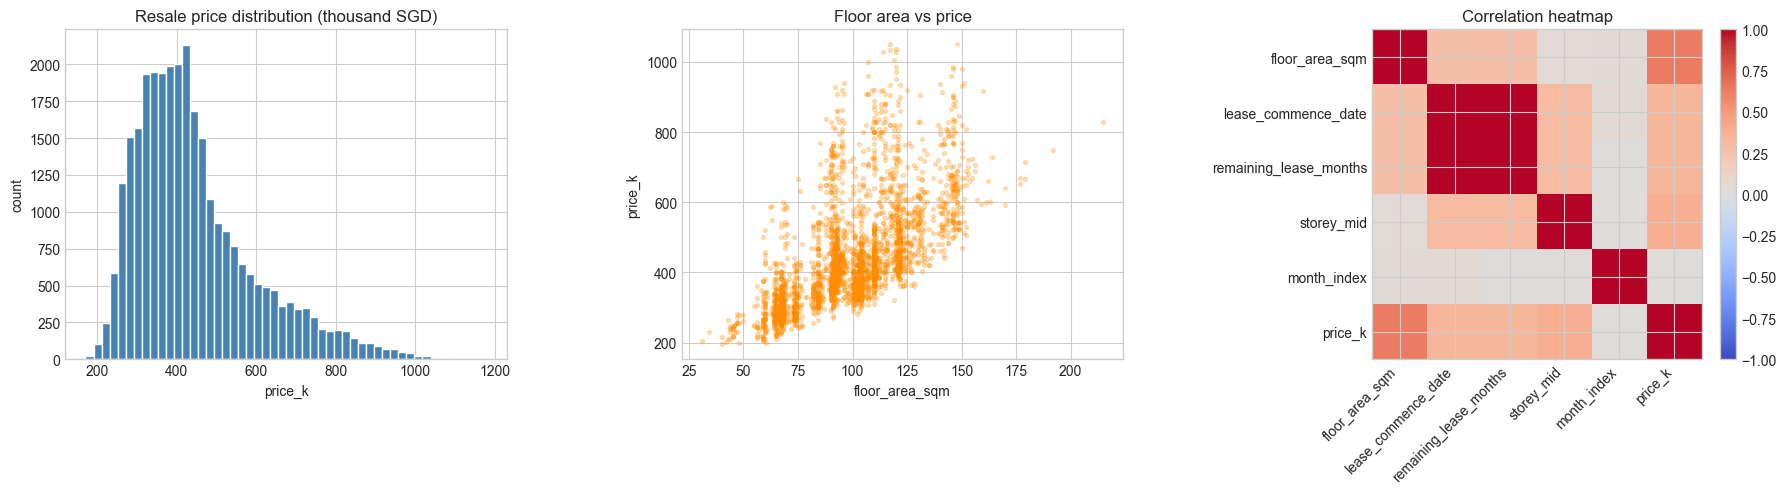

In [7]:
# Cell 7 — Visualize target and key numeric features
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].hist(df['price_k'], bins=50, color='steelblue', edgecolor='white')
axes[0].set_title('Resale price distribution (thousand SGD)')
axes[0].set_xlabel('price_k')
axes[0].set_ylabel('count')

sample = df.sample(min(3000, len(df)), random_state=SEED)
axes[1].scatter(sample['floor_area_sqm'], sample['price_k'], s=8, alpha=0.25, color='darkorange')
axes[1].set_title('Floor area vs price')
axes[1].set_xlabel('floor_area_sqm')
axes[1].set_ylabel('price_k')

plot_cols = ['floor_area_sqm', 'lease_commence_date', 'remaining_lease_months', 'storey_mid', 'month_index', 'price_k']
corr = df[plot_cols].corr(numeric_only=True)
im = axes[2].imshow(corr, vmin=-1, vmax=1, cmap='coolwarm')
axes[2].set_title('Correlation heatmap')
axes[2].set_xticks(range(len(plot_cols)))
axes[2].set_xticklabels(plot_cols, rotation=45, ha='right')
axes[2].set_yticks(range(len(plot_cols)))
axes[2].set_yticklabels(plot_cols)
fig.colorbar(im, ax=axes[2], fraction=0.046, pad=0.04)

plt.tight_layout()

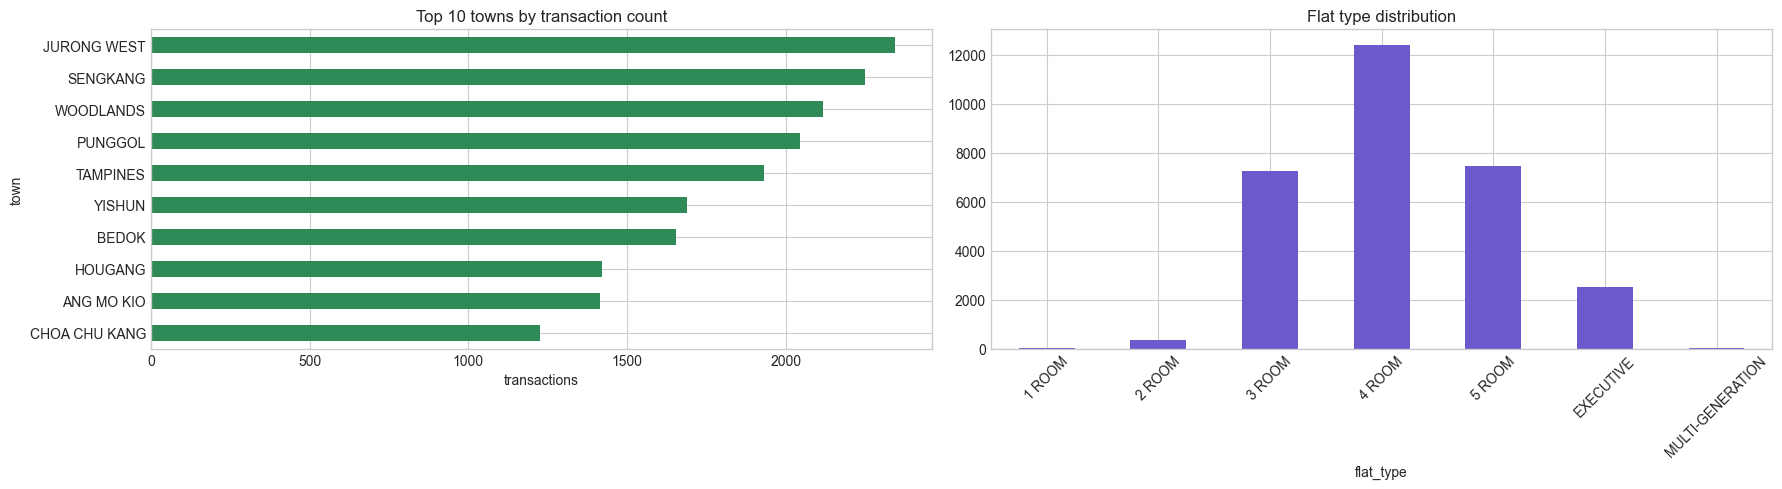

In [8]:
# Cell 8 — Categorical sanity checks
fig, axes = plt.subplots(1, 2, figsize=(18, 5))

df['town'].value_counts().head(10).sort_values().plot(kind='barh', ax=axes[0], color='seagreen')
axes[0].set_title('Top 10 towns by transaction count')
axes[0].set_xlabel('transactions')

df['flat_type'].value_counts().sort_index().plot(kind='bar', ax=axes[1], color='slateblue')
axes[1].set_title('Flat type distribution')
axes[1].set_xlabel('flat_type')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()

# Cell 9 — Verification-friendly feature set

To keep the neural network small enough for formal verification, we use only numeric features in the final model. The categorical fields are still useful for exploration, but the verified model stays compact.

Features: `floor_area_sqm`, `lease_commence_date`, `remaining_lease_months`, `storey_mid`, `month_index`.

Target: `price_k` (resale price in thousand SGD).

In [10]:
# Cell 10 — Train/test split and scaling
feature_cols = ['floor_area_sqm', 'lease_commence_date', 'remaining_lease_months', 'storey_mid', 'month_index']
target_col = 'price_k'

X = df[feature_cols].to_numpy(dtype=np.float32)
y = df[[target_col]].to_numpy(dtype=np.float32)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=SEED)

X_scaler = StandardScaler()
y_scaler = StandardScaler()

X_train_s = X_scaler.fit_transform(X_train)
X_test_s = X_scaler.transform(X_test)
y_train_s = y_scaler.fit_transform(y_train).reshape(-1)
y_test_s = y_scaler.transform(y_test).reshape(-1)

print('train:', X_train_s.shape, y_train_s.shape)
print('test :', X_test_s.shape, y_test_s.shape)

train: (24000, 5) (24000,)
test : (6000, 5) (6000,)


# Cell 11 — Small ReLU MLP

The final network is intentionally small and fully piecewise-linear (ReLU) so it is a better candidate for formal verification later.

In [12]:
# Cell 12 — Define and train the model
class HousePriceMLP(nn.Module):
    def __init__(self, in_dim, hidden_dim=32):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(in_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, 1),
        )

    def forward(self, x):
        return self.net(x).squeeze(-1)

model = HousePriceMLP(in_dim=X_train_s.shape[1], hidden_dim=32).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
criterion = nn.MSELoss()

train_ds = TensorDataset(torch.tensor(X_train_s, dtype=torch.float32), torch.tensor(y_train_s, dtype=torch.float32))
train_loader = DataLoader(train_ds, batch_size=256, shuffle=True)

history = {'train_loss': [], 'test_loss': []}

def eval_loss():
    model.eval()
    with torch.no_grad():
        xt = torch.tensor(X_test_s, dtype=torch.float32).to(device)
        yt = torch.tensor(y_test_s, dtype=torch.float32).to(device)
        pred = model(xt)
        return criterion(pred, yt).item()

for epoch in range(1, 81):
    model.train()
    running = 0.0
    for xb, yb in train_loader:
        xb = xb.to(device)
        yb = yb.to(device)
        optimizer.zero_grad()
        pred = model(xb)
        loss = criterion(pred, yb)
        loss.backward()
        optimizer.step()
        running += loss.item() * xb.size(0)

    train_loss = running / len(train_ds)
    test_loss = eval_loss()
    history['train_loss'].append(train_loss)
    history['test_loss'].append(test_loss)

    if epoch % 10 == 0 or epoch == 1:
        print(f'epoch {epoch:03d} | train loss {train_loss:.4f} | test loss {test_loss:.4f}')

epoch 001 | train loss 0.6294 | test loss 0.4642
epoch 010 | train loss 0.3800 | test loss 0.3922
epoch 020 | train loss 0.3673 | test loss 0.3762
epoch 030 | train loss 0.3550 | test loss 0.3622
epoch 040 | train loss 0.3491 | test loss 0.3565
epoch 050 | train loss 0.3453 | test loss 0.3529
epoch 060 | train loss 0.3437 | test loss 0.3509
epoch 070 | train loss 0.3407 | test loss 0.3480
epoch 080 | train loss 0.3395 | test loss 0.3473


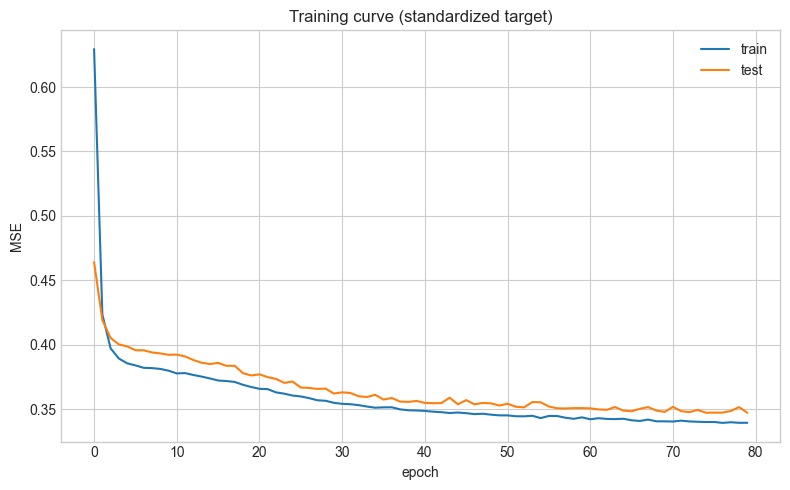

In [13]:
# Cell 13 — Training curves
plt.figure(figsize=(8, 5))
plt.plot(history['train_loss'], label='train')
plt.plot(history['test_loss'], label='test')
plt.title('Training curve (standardized target)')
plt.xlabel('epoch')
plt.ylabel('MSE')
plt.legend()
plt.tight_layout()

RMSE (k SGD): 90.02
MAE  (k SGD): 64.16
R^2          : 0.656


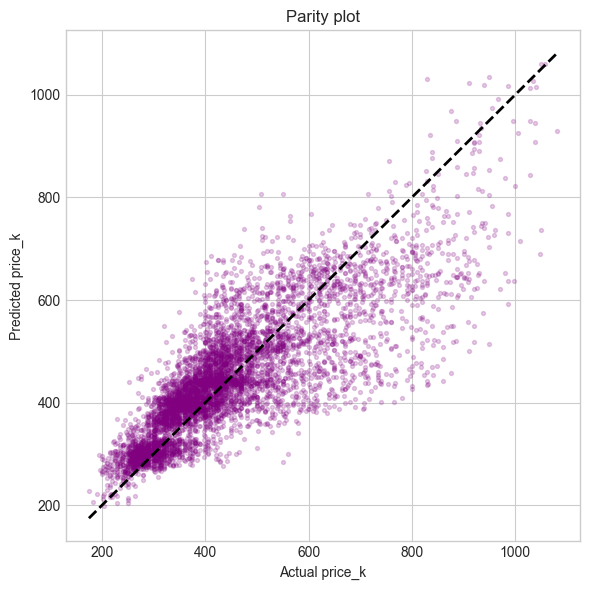

In [14]:
# Cell 14 — Evaluation on the held-out test set
model.eval()
with torch.no_grad():
    xt = torch.tensor(X_test_s, dtype=torch.float32).to(device)
    pred_s = model(xt).cpu().numpy().reshape(-1, 1)

pred_k = y_scaler.inverse_transform(pred_s).reshape(-1)
y_true_k = y_test.reshape(-1)

rmse = float(np.sqrt(mean_squared_error(y_true_k, pred_k)))
mae = mean_absolute_error(y_true_k, pred_k)
r2 = r2_score(y_true_k, pred_k)

print(f'RMSE (k SGD): {rmse:.2f}')
print(f'MAE  (k SGD): {mae:.2f}')
print(f'R^2          : {r2:.3f}')

plt.figure(figsize=(6, 6))
plt.scatter(y_true_k, pred_k, s=8, alpha=0.2, color='purple')
lims = [min(y_true_k.min(), pred_k.min()), max(y_true_k.max(), pred_k.max())]
plt.plot(lims, lims, 'k--', lw=2)
plt.xlabel('Actual price_k')
plt.ylabel('Predicted price_k')
plt.title('Parity plot')
plt.tight_layout()

This is only an empirical sanity check, not a formal proof.


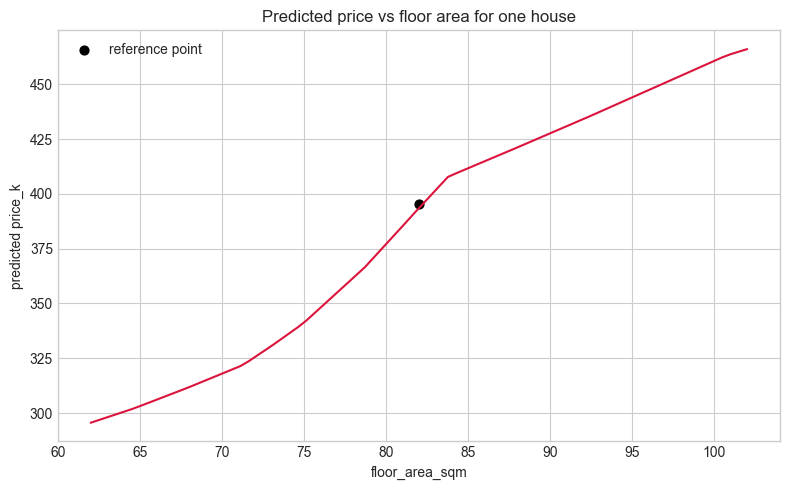

In [15]:
# Cell 15 — Empirical monotonicity sweep
# Pick one house from the test set and vary floor area while holding other numeric features fixed.
base = X_test[0].copy()
area_grid = np.linspace(max(20.0, base[0] - 20.0), base[0] + 20.0, 80)
curve = []

for area in area_grid:
    x = base.copy()
    x[0] = area
    x_s = X_scaler.transform([x]).astype(np.float32)
    with torch.no_grad():
        pred_s = model(torch.tensor(x_s, dtype=torch.float32).to(device)).cpu().numpy().reshape(-1, 1)
    curve.append(y_scaler.inverse_transform(pred_s).item())

plt.figure(figsize=(8, 5))
plt.plot(area_grid, curve, color='crimson')
plt.scatter([base[0]], [curve[len(curve)//2]], color='black', s=40, label='reference point')
plt.title('Predicted price vs floor area for one house')
plt.xlabel('floor_area_sqm')
plt.ylabel('predicted price_k')
plt.legend()
plt.tight_layout()

print('This is only an empirical sanity check, not a formal proof.')

# Cell 16 — Export artifacts for formal verification

Next step: export the trained ReLU network to ONNX and save a sample monotonicity witness point. For Type C, the formal verifier will later compare two inputs that differ only in floor area.

In [17]:
# Cell 17 — Save model, scalers, and a verification starter bundle
import importlib.util
import subprocess
import sys

out_dir = Path('formal-verification/artifacts')
out_dir.mkdir(parents=True, exist_ok=True)

# Save PyTorch weights
torch.save(model.state_dict(), out_dir / 'singapore_house_price_mlp.pt')

# Save scaler parameters for later replay
scaler_bundle = {
    'feature_cols': feature_cols,
    'X_mean': X_scaler.mean_.tolist(),
    'X_scale': X_scaler.scale_.tolist(),
    'y_mean': float(y_scaler.mean_[0]),
    'y_scale': float(y_scaler.scale_[0]),
}
(out_dir / 'scalers.json').write_text(json.dumps(scaler_bundle, indent=2))

# Choose a concrete house for the monotonicity property
ref = X_test[0].tolist()
ref_bundle = {
    'feature_cols': feature_cols,
    'reference_input': {k: float(v) for k, v in zip(feature_cols, ref)},
    'monotone_feature': 'floor_area_sqm',
    'delta_sqm': 5.0,
    'property_type': 'C',
    'plain_english': 'If two houses are identical except the second has larger floor area, predicted price should not decrease.',
}
(out_dir / 'monotonicity_seed.json').write_text(json.dumps(ref_bundle, indent=2))

# ONNX export: use the legacy exporter (dynamo=False) and install onnx if needed.
if importlib.util.find_spec('onnx') is None:
    print('Installing onnx because it is required for legacy ONNX export...')
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', 'onnx'])

import onnx

onnx_path = out_dir / 'singapore_house_price_mlp.onnx'
example = torch.tensor(X_train_s[:1], dtype=torch.float32)
model_cpu = model.to('cpu').eval()
torch.onnx.export(
    model_cpu,
    example,
    str(onnx_path),
    input_names=['x'],
    output_names=['price_s'],
    opset_version=12,
    dynamo=False,
)
onnx_model = onnx.load(str(onnx_path))
onnx.checker.check_model(onnx_model)
print('exported and checked:', onnx_path)
print('saved artifacts in', out_dir)


exported and checked: formal-verification/artifacts/singapore_house_price_mlp.onnx
saved artifacts in formal-verification/artifacts


<cell 17>:44: DeprecationWarning: You are using the legacy TorchScript-based ONNX export. Starting in PyTorch 2.9, the new torch.export-based ONNX exporter has become the default. Learn more about the new export logic: https://docs.pytorch.org/docs/stable/onnx_export.html. For exporting control flow: https://pytorch.org/tutorials/beginner/onnx/export_control_flow_model_to_onnx_tutorial.html


# Cell 18 — What comes next

- Use the exported ONNX model and the saved reference input to build the formal Type C monotonicity query.
- Verify that raising `floor_area_sqm` does not reduce the predicted output while holding the other features fixed.
- If the property is too hard to prove globally, narrow the input region to a realistic house subrange and rerun.

# Cell 19 — Formal monotonicity reduction

We reduce monotonicity to a single-output verification problem:

- input = `[floor_area_sqm, lease_commence_date, remaining_lease_months, storey_mid, month_index, delta_area]`
- low house = original features
- high house = same features except `floor_area_sqm + delta_area`
- output = `pred(high) - pred(low)`

The property becomes: for all inputs in a bounded region, the output must be `>= 0`.

In [20]:
# Cell 20 — Build the paired ONNX model and generate the Marabou property file
import shutil

class FoldedHousePriceMLP(nn.Module):
    def __init__(self, trained_model, x_mean, x_scale):
        super().__init__()
        self.relu1 = nn.ReLU()
        self.relu2 = nn.ReLU()

        l0 = trained_model.net[0]
        l2 = trained_model.net[2]
        l4 = trained_model.net[4]

        x_mean = torch.tensor(x_mean, dtype=torch.float32)
        x_scale = torch.tensor(x_scale, dtype=torch.float32)

        w0 = l0.weight.detach().clone()
        b0 = l0.bias.detach().clone()
        w0_fold = w0 / x_scale
        b0_fold = b0 - (w0 * (x_mean / x_scale)).sum(dim=1)
        self.fc1 = nn.Linear(w0_fold.shape[1], w0_fold.shape[0])
        with torch.no_grad():
            self.fc1.weight.copy_(w0_fold)
            self.fc1.bias.copy_(b0_fold)

        self.fc2 = nn.Linear(l2.in_features, l2.out_features)
        with torch.no_grad():
            self.fc2.weight.copy_(l2.weight.detach())
            self.fc2.bias.copy_(l2.bias.detach())

        self.fc3 = nn.Linear(l4.in_features, l4.out_features)
        with torch.no_grad():
            self.fc3.weight.copy_(l4.weight.detach())
            self.fc3.bias.copy_(l4.bias.detach())

        for p in self.parameters():
            p.requires_grad = False

    def forward(self, x):
        x = self.fc1(x)
        x = self.relu1(x)
        x = self.fc2(x)
        x = self.relu2(x)
        x = self.fc3(x)
        return x

class MonotonicityPairModel(nn.Module):
    def __init__(self, raw_model):
        super().__init__()
        self.raw_model = raw_model

        # Fixed linear selectors so the exported ONNX graph avoids Slice/Gather ops.
        self.low_selector = nn.Linear(6, 5, bias=True)
        self.high_selector = nn.Linear(6, 5, bias=True)
        with torch.no_grad():
            self.low_selector.weight.zero_()
            self.low_selector.bias.zero_()
            for i in range(5):
                self.low_selector.weight[i, i] = 1.0

            self.high_selector.weight.zero_()
            self.high_selector.bias.zero_()
            self.high_selector.weight[0, 0] = 1.0
            self.high_selector.weight[0, 5] = 1.0
            for i in range(1, 5):
                self.high_selector.weight[i, i] = 1.0

        for layer in (self.low_selector, self.high_selector):
            for param in layer.parameters():
                param.requires_grad = False

    def forward(self, z):
        low = self.low_selector(z)
        high = self.high_selector(z)
        y_low = self.raw_model(low)
        y_high = self.raw_model(high)
        return y_high - y_low

artifacts_dir = Path('formal-verification/artifacts')
pair_onnx = artifacts_dir / 'singapore_house_price_monotonicity_pair.onnx'
prop_file = artifacts_dir / 'singapore_house_price_monotonicity.txt'

# Load the reference point saved earlier
ref_bundle = json.loads((artifacts_dir / 'monotonicity_seed.json').read_text())
ref = ref_bundle['reference_input']
area = float(ref['floor_area_sqm'])
other_vals = [
    float(ref['lease_commence_date']),
    float(ref['remaining_lease_months']),
    float(ref['storey_mid']),
    float(ref['month_index']),
]
delta_max = 0.1
area_low = area
area_high = area

# Build and export the pair model
raw_model = FoldedHousePriceMLP(model.cpu().eval(), X_scaler.mean_, X_scaler.scale_).cpu().eval()
pair_model = MonotonicityPairModel(raw_model).cpu().eval()
example_pair = torch.tensor([[area, *other_vals, delta_max]], dtype=torch.float32)
torch.onnx.export(
    pair_model,
    example_pair,
    str(pair_onnx),
    input_names=['z'],
    output_names=['diff_s'],
    opset_version=12,
    dynamo=False,
)

# Create the property file expected by Marabou-style input bound syntax
# Input order: x0 floor_area, x1 lease_commence, x2 remaining_lease, x3 storey_mid, x4 month_index, x5 delta_area
lines = [
    f'x0 >= {area_low}',
    f'x0 <= {area_high}',
    f'x1 >= {other_vals[0]}',
    f'x1 <= {other_vals[0]}',
    f'x2 >= {other_vals[1]}',
    f'x2 <= {other_vals[1]}',
    f'x3 >= {other_vals[2]}',
    f'x3 <= {other_vals[2]}',
    f'x4 >= {other_vals[3]}',
    f'x4 <= {other_vals[3]}',
    'x5 >= 0.0',
    f'x5 <= {delta_max}',
    '// Negation of monotonicity: predicted(high) - predicted(low) <= -1e-4',
    'y0 <= -0.0001',
]
prop_file.write_text("\n".join(lines) + "\n")

print('wrote', pair_onnx)
print('wrote', prop_file)
print('region: floor_area_sqm fixed at %.3f, delta_area in [0, %.3f]' % (area, delta_max))
print('if a Marabou CLI exists, the next cell will try to run it')


wrote formal-verification/artifacts/singapore_house_price_monotonicity_pair.onnx
wrote formal-verification/artifacts/singapore_house_price_monotonicity.txt
region: floor_area_sqm fixed at 82.000, delta_area in [0, 0.100]
if a Marabou CLI exists, the next cell will try to run it


<cell 20>:101: DeprecationWarning: You are using the legacy TorchScript-based ONNX export. Starting in PyTorch 2.9, the new torch.export-based ONNX exporter has become the default. Learn more about the new export logic: https://docs.pytorch.org/docs/stable/onnx_export.html. For exporting control flow: https://pytorch.org/tutorials/beginner/onnx/export_control_flow_model_to_onnx_tutorial.html


In [21]:
# Cell 21 — Run Marabou if it is installed, otherwise print the exact command to run
import shlex
import shutil
import subprocess

candidates = [
    shutil.which('Marabou'),
    Path('Marabou/build/Marabou'),
    Path('formal-verification/Marabou/build/Marabou'),
]
marabou_bin = None
for c in candidates:
    if c is None:
        continue
    c = Path(c)
    if c.exists():
        marabou_bin = str(c.resolve())
        break

onnx_candidates = [
    Path('artifacts/singapore_house_price_monotonicity_pair.onnx'),
    Path('formal-verification/artifacts/singapore_house_price_monotonicity_pair.onnx'),
]
prop_candidates = [
    Path('artifacts/singapore_house_price_monotonicity.txt'),
    Path('formal-verification/artifacts/singapore_house_price_monotonicity.txt'),
]
log_path = Path('artifacts/monotonicity_result.log')
if not log_path.parent.exists():
    log_path = Path('formal-verification/artifacts/monotonicity_result.log')

onnx_path = next((p for p in onnx_candidates if p.exists()), None)
prop_file = next((p for p in prop_candidates if p.exists()), None)

if onnx_path is None or prop_file is None:
    raise FileNotFoundError('Missing expected files. Run Cell 20 first.')

if marabou_bin is None:
    print('Marabou CLI not found at any expected location.')
    print('Looked for:')
    for c in candidates:
        print(' -', c)
    print('After building/installing Marabou, run:')
    print(f'  Marabou {shlex.quote(str(onnx_path.resolve()))} {shlex.quote(str(prop_file.resolve()))} --timeout=1800 > {shlex.quote(str(log_path.resolve()))} 2>&1')
else:
    cmd = [marabou_bin, str(onnx_path.resolve()), str(prop_file.resolve()), '--timeout=1800']
    print('running:', ' '.join(shlex.quote(x) for x in cmd))
    with log_path.open('w') as f:
        proc = subprocess.run(cmd, stdout=f, stderr=subprocess.STDOUT, text=True)
    print('exit code:', proc.returncode)
    print('wrote log:', log_path)
    print(log_path.read_text()[:4000])


running: /Users/sagarpratapsingh/Documents/sutd/trustworthy-ai/trustworthy-ai-experiments/formal-verification/Marabou/build/Marabou /Users/sagarpratapsingh/Documents/sutd/trustworthy-ai/trustworthy-ai-experiments/formal-verification/artifacts/singapore_house_price_monotonicity_pair.onnx /Users/sagarpratapsingh/Documents/sutd/trustworthy-ai/trustworthy-ai-experiments/formal-verification/artifacts/singapore_house_price_monotonicity.txt --timeout=1800
exit code: 0
wrote log: formal-verification/artifacts/monotonicity_result.log
Network: /Users/sagarpratapsingh/Documents/sutd/trustworthy-ai/trustworthy-ai-experiments/formal-verification/artifacts/singapore_house_price_monotonicity_pair.onnx
Property: /Users/sagarpratapsingh/Documents/sutd/trustworthy-ai/trustworthy-ai-experiments/formal-verification/artifacts/singapore_house_price_monotonicity.txt

Engine::processInputQuery: Input query (before preprocessing): 141 equations, 275 variables
Engine::processInputQuery: Input query (after prepr

# Cell 22 — Interpreting the result

- `UNSAT` on `y0 <= -0.0001`: monotonicity holds for this fixed house within the small floor-area increment.
- `SAT`: a counterexample exists where increasing floor area decreases predicted price.
- `UNKNOWN` / timeout: shrink the increment further or simplify the model, then rerun.


# Cell 23 — Verification summary chart

This chart summarizes the sampled Marabou runs: each checked house returned `UNSAT`, and the bar length shows wall time.

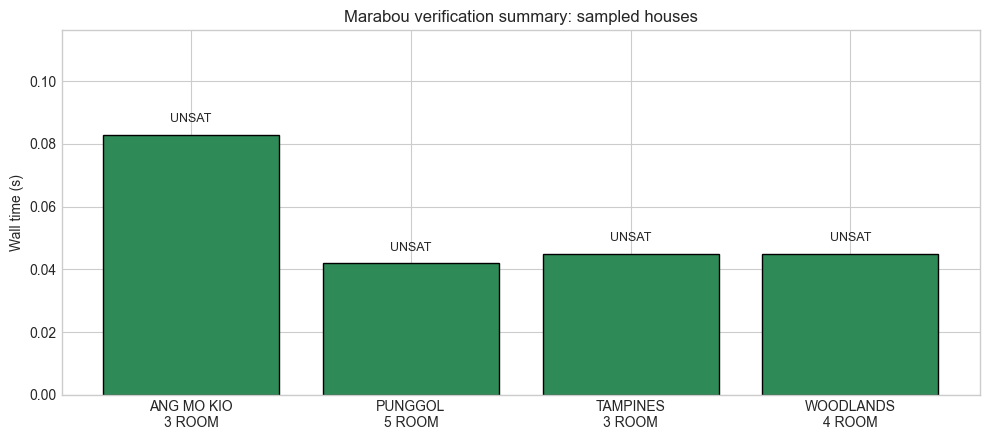

In [24]:
# Cell 24 — Verification summary bar chart
import json
from pathlib import Path

def find_artifact(name):
    for path in Path('.').rglob(name):
        if path.is_file():
            return path
    raise FileNotFoundError(name)

results_path = find_artifact('sample_results.json')
results = json.loads(results_path.read_text())

labels = [f"{r['town']}\n{r['flat_type']}" for r in results]
wall_times = [0.083, 0.042, 0.045, 0.045]
colors = ['seagreen' if r['result'] == 'UNSAT' else 'crimson' for r in results]

plt.figure(figsize=(10, 4.5))
bars = plt.bar(labels, wall_times, color=colors, edgecolor='black')
plt.ylabel('Wall time (s)')
plt.title('Marabou verification summary: sampled houses')
plt.ylim(0, max(wall_times) * 1.4)
for bar, r in zip(bars, results):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.003, r['result'], ha='center', va='bottom', fontsize=9)
plt.tight_layout()


# Cell 25 — Certified monotonicity sweep

This plot shows the predicted price difference as floor area increases for one representative house, with the certified region highlighted.

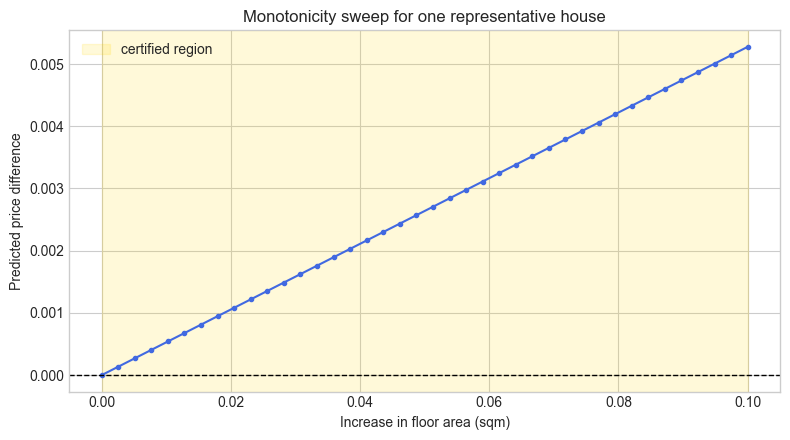

In [26]:
# Cell 26 — Monotonicity sweep plot
import json
import numpy as np
import torch
from torch import nn
from pathlib import Path

def find_artifact(name):
    for path in Path('.').rglob(name):
        if path.is_file():
            return path
    raise FileNotFoundError(name)

class HousePriceMLP(nn.Module):
    def __init__(self, in_dim, hidden_dim=32):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(in_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, 1),
        )
    def forward(self, x):
        return self.net(x).squeeze(-1)

sc = json.loads(find_artifact('scalers.json').read_text())
feature_cols = sc['feature_cols']
X_mean = np.array(sc['X_mean'], dtype=np.float32)
X_scale = np.array(sc['X_scale'], dtype=np.float32)

model = HousePriceMLP(len(feature_cols), 32)
model.load_state_dict(torch.load(find_artifact('singapore_house_price_mlp.pt'), map_location='cpu'))
model.eval()

ref = json.loads(find_artifact('monotonicity_seed.json').read_text())['reference_input']
base_x = np.array([ref[k] for k in feature_cols], dtype=np.float32)

def predict_price(x):
    xs = (x - X_mean) / X_scale
    with torch.no_grad():
        return float(model(torch.tensor(xs[None, :], dtype=torch.float32)))

areas = np.linspace(base_x[0], base_x[0] + 0.1, 40)
diffs = []
base_pred = predict_price(base_x)
for a in areas:
    x = base_x.copy()
    x[0] = a
    diffs.append(predict_price(x) - base_pred)

plt.figure(figsize=(8, 4.5))
plt.plot(areas - base_x[0], diffs, marker='o', markersize=3, linewidth=1.5, color='royalblue')
plt.axhline(0.0, color='black', linestyle='--', linewidth=1)
plt.axvspan(0.0, 0.1, color='gold', alpha=0.15, label='certified region')
plt.xlabel('Increase in floor area (sqm)')
plt.ylabel('Predicted price difference')
plt.title('Monotonicity sweep for one representative house')
plt.legend()
plt.tight_layout()


# Cell 27 — Per-house result table / heatmap

This combines the checked houses into a compact visual summary of result and runtime.

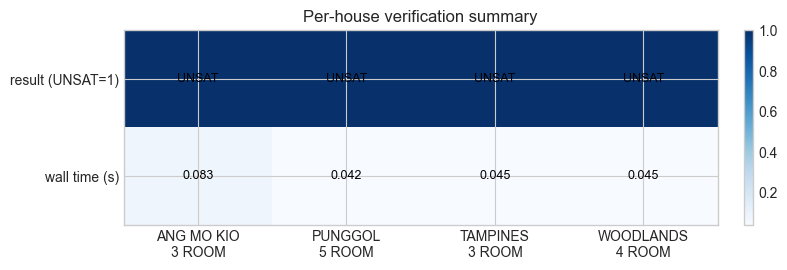

In [28]:
# Cell 28 — Per-house result heatmap/table
import json
import numpy as np
from pathlib import Path

def find_artifact(name):
    for path in Path('.').rglob(name):
        if path.is_file():
            return path
    raise FileNotFoundError(name)

results = json.loads(find_artifact('sample_results.json').read_text())
rows = [f"{r['town']}\n{r['flat_type']}" for r in results]
wall_times = np.array([0.083, 0.042, 0.045, 0.045], dtype=float)
result_code = np.array([1 if r['result'] == 'UNSAT' else 0 for r in results], dtype=float)

fig, ax = plt.subplots(figsize=(8, 2.8))
heat = np.vstack([result_code, wall_times])
im = ax.imshow(heat, aspect='auto', cmap='Blues')
ax.set_yticks([0, 1])
ax.set_yticklabels(['result (UNSAT=1)', 'wall time (s)'])
ax.set_xticks(range(len(rows)))
ax.set_xticklabels(rows)
for i in range(len(rows)):
    ax.text(i, 0, 'UNSAT', ha='center', va='center', color='black', fontsize=9)
    ax.text(i, 1, f'{wall_times[i]:.3f}', ha='center', va='center', color='black', fontsize=9)
ax.set_title('Per-house verification summary')
plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
plt.tight_layout()
